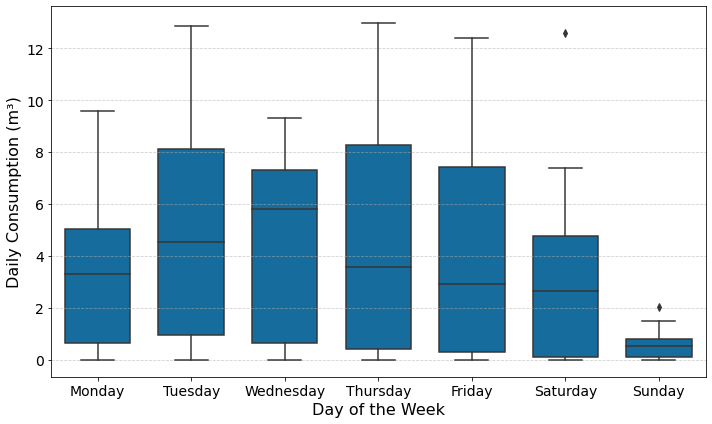

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# Detect the repository root
current_dir = Path.cwd()

if (current_dir / "data").exists():
    repository_root = current_dir
elif (current_dir.parent / "data").exists():
    repository_root = current_dir.parent
else:
    raise FileNotFoundError(
        "The repository data directory could not be found. "
        "Run the notebook from the repository root or from the notebooks directory."
    )

# Dataset path
data_path = repository_root / "data" / "Dataset_Consumo_Shifts_v2.xlsx"

# Verify that the dataset exists
if not data_path.exists():
    raise FileNotFoundError(
        "Dataset not found. Place 'Dataset_Consumo_Shifts_v2.xlsx' "
        "inside the repository data directory."
    )

# Load the dataset
df = pd.read_excel(data_path)

# Verify required columns
required_columns = ["Fecha", "Consumo"]

missing = [col for col in required_columns if col not in df.columns]
if missing:
    raise KeyError(
        f"The dataset is missing the following required columns: {missing}"
    )

# Convert dates and create weekday labels
df["Fecha"] = pd.to_datetime(df["Fecha"])
df["Weekday"] = df["Fecha"].dt.day_name()

# Weekday order
weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

# Create the figure
fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Weekday",
    y="Consumo",
    order=weekday_order,
    color="#0072B2",
    width=0.7,
    ax=ax
)

# Axis labels and formatting
ax.set_xlabel("Day of the Week", fontsize=16)
ax.set_ylabel("Daily Consumption (m³)", fontsize=16)
ax.tick_params(axis="both", labelsize=14)
ax.grid(True, axis="y", linestyle="--", alpha=0.6)

fig.tight_layout()
plt.show()